# 02 — EDA: impacto do `text_processing` no treino

Avalia, **descritivamente**, o efeito da remocao de stopwords PT-BR
(`economy_classifier.text_processing`) sobre o split de **treino**
(`artifacts/splits/train.parquet`, coluna `text` — a mesma entrada do pipeline
TF-IDF/BERT).

Objetivo: dar suporte empirico a decisao dos runs `_nostop` (flag
`remove_stopwords`). Nao treina modelo nem reporta metricas de classificacao —
so quantifica **o que a remocao muda no insumo**.

**Roteiro**
1. Inventario da lista de stopwords.
2. Cobertura: fracao de tokens que sao stopword (corpus e por documento).
3. Impacto no comprimento dos documentos (tokens e caracteres).
4. Casos-limite: documentos que ficam vazios / muito curtos apos a remocao.
5. Tokens mais removidos.
6. Impacto no vocabulario TF-IDF (tamanho, esparsidade) com vs. sem stopwords.
7. Estratificacao por classe — a remocao atinge `mercado` diferente de `outros`?
8. Exemplos qualitativos antes/depois.
9. Sanidade (idempotencia).

> **Guardia metodologica.** Toda a analise roda **so no treino**. Val/test
> permanecem intocados (refletem a distribuicao real e nunca sao usados para
> decisao de pre-processamento).

## 0. Bootstrap (Colab + local)

Detecta o ambiente, monta o Drive em Colab, clona o repo e instala o pacote, e
seleciona `SPLITS_DIR` / `FIG_DIR`. Em Colab os splits saem de
`My Drive/economy-classifier/colab_splits.zip` (gerado por `scripts/colab_pack.py`).

In [1]:
import subprocess
import sys
import zipfile
from pathlib import Path


def _run(cmd: list[str], description: str) -> None:
    print(f"$ {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr, file=sys.stderr)
        raise RuntimeError(f"{description} failed with exit code {result.returncode}")


IN_COLAB = "google.colab" in sys.modules
print("Ambiente:", "Google Colab" if IN_COLAB else "Local")

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    REPO_URL = "https://github.com/almeidadm/economy-classifier.git"
    REPO_BRANCH = "main"
    DRIVE_FOLDER = "economy-classifier"

    DRIVE_BASE = Path("/content/drive/MyDrive") / DRIVE_FOLDER
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)
    REPO_DIR = Path("/content/economy-classifier")

    if REPO_DIR.exists():
        _run(["git", "-C", str(REPO_DIR), "fetch", "origin", REPO_BRANCH], "git fetch")
        _run(["git", "-C", str(REPO_DIR), "checkout", REPO_BRANCH], "git checkout")
        _run(["git", "-C", str(REPO_DIR), "reset", "--hard", f"origin/{REPO_BRANCH}"], "git reset")
    else:
        _run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(REPO_DIR)], "git clone")

    _run(
        [sys.executable, "-m", "pip", "install", "-e", str(REPO_DIR),
         "--upgrade-strategy", "only-if-needed", "-q"],
        "pip install -e .",
    )
    if str(REPO_DIR / "src") not in sys.path:
        sys.path.insert(0, str(REPO_DIR / "src"))

    SPLITS_DIR = REPO_DIR / "artifacts" / "splits"
    if not (SPLITS_DIR / "train.parquet").exists():
        zip_path = DRIVE_BASE / "colab_splits.zip"
        assert zip_path.exists(), (
            f"Falta colab_splits.zip em {DRIVE_BASE}. Rode scripts/colab_pack.py local e suba o zip."
        )
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(REPO_DIR / "artifacts")
        print("Splits extraidos em", SPLITS_DIR)

    FIG_DIR = DRIVE_BASE / "figures" / "eda_text_processing"
else:
    REPO_DIR = Path.cwd().parent
    SPLITS_DIR = REPO_DIR / "artifacts" / "splits"
    FIG_DIR = REPO_DIR / "artifacts" / "figures" / "eda_text_processing"

FIG_DIR.mkdir(parents=True, exist_ok=True)
print("SPLITS_DIR:", SPLITS_DIR)
print("FIG_DIR   :", FIG_DIR)

Ambiente: Local
SPLITS_DIR: /home/diacrono/Documentos/repositorios/economy-classifier/artifacts/splits
FIG_DIR   : /home/diacrono/Documentos/repositorios/economy-classifier/artifacts/figures/eda_text_processing


## 1. Imports e configuracao

In [2]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

from economy_classifier.datasets import MULTICLASS_TOP7, OTHER_LABEL
from economy_classifier.text_processing import (
    load_stopwords_pt,
    strip_stopwords,
    tfidf_stop_words,
    _WORD_RE,       # mesmo tokenizador-palavra usado pela remocao
    _normalize,     # lowercase + strip-accents (espaco de comparacao de stopwords)
)

SEED = 2026
# A varredura por-documento (strip_stopwords token a token) e O(n_tokens). Amostra
# para manter o notebook responsivo; o ajuste do vetorizador (secao 6) usa o treino
# inteiro. Suba para len(train) para a analise exaustiva.
SAMPLE_N = 20_000

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (8, 4.5)
STOPWORDS = load_stopwords_pt()
LABELS_MULTI = list(MULTICLASS_TOP7) + [OTHER_LABEL]

In [3]:
train = pd.read_parquet(SPLITS_DIR / "train.parquet")
train["text"] = train["text"].fillna("")
print("treino:", train.shape)
print("colunas:", list(train.columns))
print("\ndist. binaria (label):")
print(train["label"].value_counts(normalize=True).rename({0: "outros", 1: "mercado"}).round(4))
print("\ndist. multiclasse (label_multi):")
print(train["label_multi"].value_counts(normalize=True).round(4))

treino: (133030, 8)
colunas: ['title', 'text', 'date', 'category', 'subcategory', 'link', 'label', 'label_multi']

dist. binaria (label):
label
outros     0.8739
mercado    0.1261
Name: proportion, dtype: float64

dist. multiclasse (label_multi):
label_multi
outros       0.1942
poder        0.1322
colunas      0.1298
mercado      0.1261
esporte      0.1181
mundo        0.1027
cotidiano    0.1022
ilustrada    0.0947
Name: proportion, dtype: double[pyarrow]


## 2. Inventario da lista de stopwords

A lista vem de `data/stopwords_pt.txt` (NLTK PT-BR materializado), ja normalizada
para o espaco de tokens do `TfidfVectorizer` (lowercase + `strip_accents='unicode'`).

In [4]:
sw_sorted = tfidf_stop_words()
print(f"# stopwords: {len(sw_sorted)}")
print(f"comprimento dos termos: min={min(map(len, sw_sorted))}, "
      f"max={max(map(len, sw_sorted))}, "
      f"media={np.mean([len(w) for w in sw_sorted]):.2f}")
print("\namostra (50 primeiras):")
print(", ".join(sw_sorted[:50]))
# todas ascii (acentos removidos) e minusculas — contrato de normalizacao
assert all(w == w.lower() and w.isascii() for w in sw_sorted)
print("\nOK: lista 100% normalizada (lowercase, sem acento).")

# stopwords: 200
comprimento dos termos: min=1, max=12, media=5.11

amostra (50 primeiras):
a, ao, aos, aquela, aquelas, aquele, aqueles, aquilo, as, ate, com, como, da, das, de, dela, delas, dele, deles, depois, do, dos, e, ela, elas, ele, eles, em, entre, era, eram, eramos, essa, essas, esse, esses, esta, estamos, estao, estar, estas, estava, estavam, estavamos, este, esteja, estejam, estejamos, estes, esteve

OK: lista 100% normalizada (lowercase, sem acento).


## 3. Cobertura: fracao de tokens que sao stopword

Tokeniza cada documento com o **mesmo** `_WORD_RE` da remocao, normaliza
(`_normalize`) e conta quantos tokens caem na lista. Reporta a cobertura
agregada do corpus e a distribuicao por documento.

In [5]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(train.index, size=min(SAMPLE_N, len(train)), replace=False)
sample = train.loc[sample_idx].copy()
print(f"amostra para analise por-documento: {len(sample)} docs")


def token_stats(text: str) -> tuple[int, int]:
    """(# tokens-palavra, # tokens-stopword) na forma normalizada."""
    toks = _WORD_RE.findall(text)
    n_sw = sum(1 for t in toks if _normalize(t) in STOPWORDS)
    return len(toks), n_sw


tot = sample["text"].map(token_stats)
sample["n_tokens"] = tot.map(lambda p: p[0])
sample["n_stop"] = tot.map(lambda p: p[1])
sample["n_kept"] = sample["n_tokens"] - sample["n_stop"]
# fracao de stopwords por doc (evita /0 em doc vazio)
sample["stop_frac"] = np.where(sample["n_tokens"] > 0,
                               sample["n_stop"] / sample["n_tokens"], 0.0)

total_tokens = int(sample["n_tokens"].sum())
total_stop = int(sample["n_stop"].sum())
print(f"tokens totais (amostra) : {total_tokens:,}")
print(f"tokens stopword         : {total_stop:,}")
print(f"cobertura agregada      : {total_stop / total_tokens:.1%} dos tokens sao stopword")
print(f"\nfracao de stopword por doc — descritiva:")
print(sample["stop_frac"].describe(percentiles=[.05, .25, .5, .75, .95]).round(4))

amostra para analise por-documento: 20000 docs


tokens totais (amostra) : 9,031,535
tokens stopword         : 3,740,749
cobertura agregada      : 41.4% dos tokens sao stopword

fracao de stopword por doc — descritiva:
count    20000.0000
mean         0.4082
std          0.0439
min          0.0000
5%           0.3452
25%          0.3927
50%          0.4129
75%          0.4316
95%          0.4608
max          0.6000
Name: stop_frac, dtype: float64


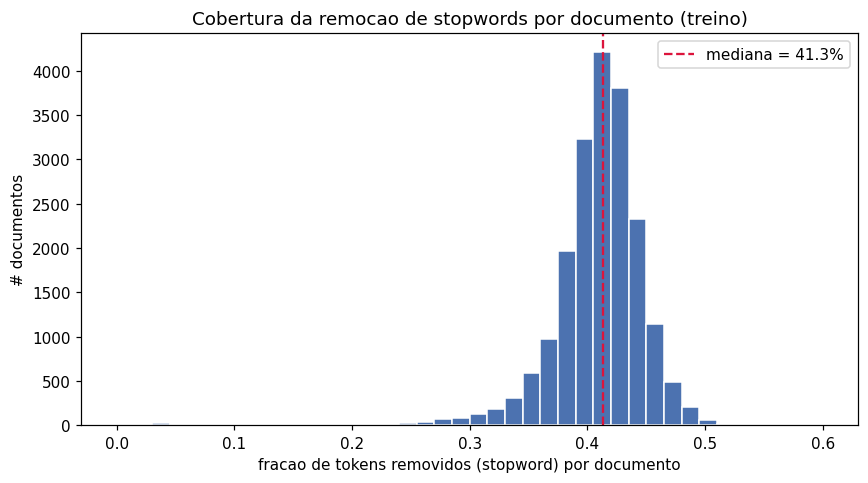

In [6]:
fig, ax = plt.subplots()
ax.hist(sample["stop_frac"], bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(sample["stop_frac"].median(), color="crimson", ls="--",
           label=f"mediana = {sample['stop_frac'].median():.1%}")
ax.set_xlabel("fracao de tokens removidos (stopword) por documento")
ax.set_ylabel("# documentos")
ax.set_title("Cobertura da remocao de stopwords por documento (treino)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "stop_frac_hist.png", bbox_inches="tight")
plt.show()

## 4. Impacto no comprimento dos documentos

Aplica `strip_stopwords` (o caminho upstream usado pelo BERT) e compara o
comprimento antes/depois em **tokens** e **caracteres**. O encolhimento medio
dimensiona quanto sinal de superficie a remocao retira.

In [7]:
sample["text_nostop"] = sample["text"].map(strip_stopwords)
sample["n_tokens_after"] = sample["text_nostop"].map(lambda t: len(_WORD_RE.findall(t)))
sample["chars_before"] = sample["text"].str.len()
sample["chars_after"] = sample["text_nostop"].str.len()

tok_red = 1 - sample["n_tokens_after"].sum() / max(sample["n_tokens"].sum(), 1)
chr_red = 1 - sample["chars_after"].sum() / max(sample["chars_before"].sum(), 1)
print(f"reducao agregada de tokens     : {tok_red:.1%}")
print(f"reducao agregada de caracteres : {chr_red:.1%}")

comp = pd.DataFrame({
    "tokens_antes": sample["n_tokens"].describe(),
    "tokens_depois": sample["n_tokens_after"].describe(),
    "chars_antes": sample["chars_before"].describe(),
    "chars_depois": sample["chars_after"].describe(),
}).round(1)
comp

reducao agregada de tokens     : 41.4%
reducao agregada de caracteres : 23.1%


,tokens_antes,tokens_depois,chars_antes,chars_depois
count,20000.0,20000.0,20000.0,20000.0
mean,451.6,264.5,2729.2,2097.6
std,316.4,183.0,1925.7,1467.0
min,3.0,2.0,14.0,9.0
25%,257.0,153.0,1552.0,1201.0
50%,403.0,236.0,2439.0,1882.0
75%,570.0,333.0,3451.0,2654.0
max,8779.0,4860.0,56878.0,43065.0


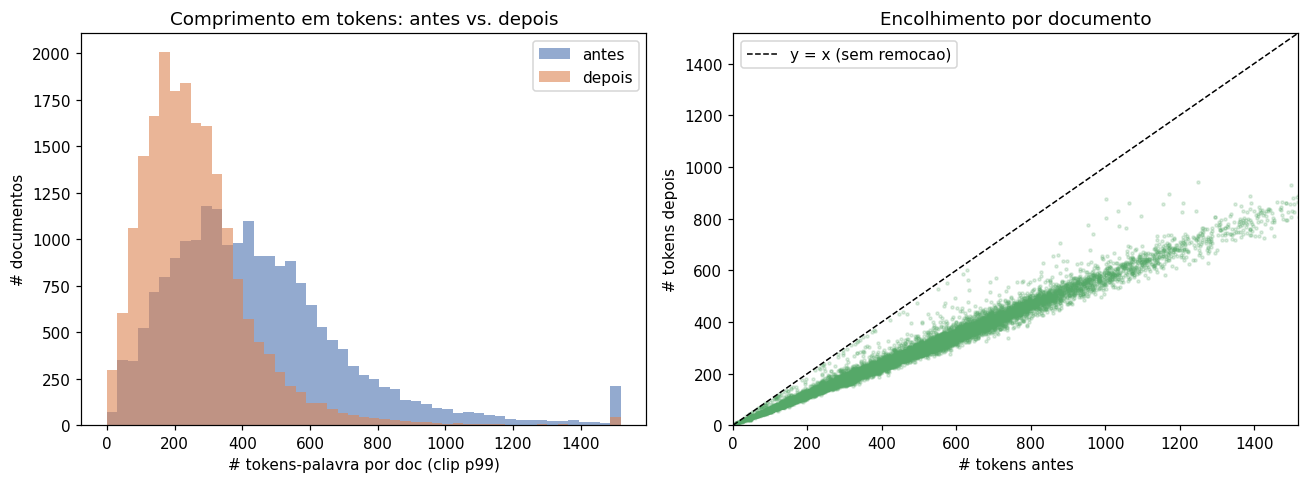

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
clip = sample["n_tokens"].quantile(0.99)
bins = np.linspace(0, clip, 50)
axes[0].hist(sample["n_tokens"].clip(upper=clip), bins=bins, alpha=0.6,
             label="antes", color="#4C72B0")
axes[0].hist(sample["n_tokens_after"].clip(upper=clip), bins=bins, alpha=0.6,
             label="depois", color="#DD8452")
axes[0].set_xlabel("# tokens-palavra por doc (clip p99)")
axes[0].set_ylabel("# documentos")
axes[0].set_title("Comprimento em tokens: antes vs. depois")
axes[0].legend()

axes[1].scatter(sample["n_tokens"], sample["n_tokens_after"], s=4, alpha=0.2,
                color="#55A868")
lim = sample["n_tokens"].quantile(0.99)
axes[1].plot([0, lim], [0, lim], "k--", lw=1, label="y = x (sem remocao)")
axes[1].set_xlim(0, lim); axes[1].set_ylim(0, lim)
axes[1].set_xlabel("# tokens antes"); axes[1].set_ylabel("# tokens depois")
axes[1].set_title("Encolhimento por documento")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "length_before_after.png", bbox_inches="tight")
plt.show()

## 5. Casos-limite: documentos esvaziados pela remocao

Documentos que ficam **vazios** ou **muito curtos** (< 3 tokens) apos a remocao
sao um risco: viram vetores quase-nulos no TF-IDF e perdem conteudo para o BERT.
Quantos sao? De que classe? Isso e material para a ressalva metodologica do BERT
`_nostop`.

In [9]:
empty_after = sample["n_tokens_after"] == 0
tiny_after = sample["n_tokens_after"] < 3
print(f"docs vazios apos remocao      : {empty_after.sum()} ({empty_after.mean():.3%})")
print(f"docs com < 3 tokens apos       : {tiny_after.sum()} ({tiny_after.mean():.3%})")

if tiny_after.any():
    print("\nclasse (label_multi) dos docs encurtados a < 3 tokens:")
    print(sample.loc[tiny_after, "label_multi"].value_counts())
    print("\nexemplos (texto original -> apos remocao):")
    for _, row in sample.loc[tiny_after].head(5).iterrows():
        print(f"  [{row['label_multi']}] {row['text'][:90]!r}")
        print(f"      -> {row['text_nostop'][:90]!r}")
else:
    print("\nNenhum documento ficou abaixo de 3 tokens na amostra.")

docs vazios apos remocao      : 0 (0.000%)
docs com < 3 tokens apos       : 11 (0.055%)

classe (label_multi) dos docs encurtados a < 3 tokens:
label_multi
colunas    7
outros     4
Name: count, dtype: int64[pyarrow]

exemplos (texto original -> apos remocao):
  [outros] 'Leia mais aqui'
      -> 'Leia aqui'
  [outros] 'Leia a reportagem'
      -> 'Leia reportagem'
  [colunas] 'A colunista está em férias.'
      -> 'colunista férias.'
  [colunas] 'O colunista está de férias'
      -> 'colunista férias'
  [colunas] 'A colunista está em férias'
      -> 'colunista férias'


## 6. Impacto no vocabulario TF-IDF (com vs. sem stopwords)

Replica exatamente a config do pipeline (`ngram_range=(1,2)`, `min_df=2`,
`max_df=0.95`, `strip_accents='unicode'`, `lowercase=True`) e ajusta o
vetorizador no **treino inteiro** com e sem `stop_words`. Compara tamanho de
vocabulario, nnz e esparsidade — o que a flag `remove_stopwords` muda no insumo
real do classificador.

In [10]:
def fit_vectorizer(remove_stopwords: bool) -> TfidfVectorizer:
    vec = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        strip_accents="unicode",
        lowercase=True,
        stop_words=tfidf_stop_words() if remove_stopwords else None,
    )
    vec.fit(train["text"].tolist())
    return vec


vec_full = fit_vectorizer(remove_stopwords=False)
vec_nostop = fit_vectorizer(remove_stopwords=True)


def vocab_profile(vec: TfidfVectorizer, X) -> dict:
    feats = vec.get_feature_names_out()
    is_bigram = np.array([" " in f for f in feats])
    return {
        "vocab": len(feats),
        "unigramas": int((~is_bigram).sum()),
        "bigramas": int(is_bigram.sum()),
        "nnz": int(X.nnz),
        "densidade": X.nnz / (X.shape[0] * X.shape[1]),
    }


X_full = vec_full.transform(train["text"].tolist())
X_nostop = vec_nostop.transform(train["text"].tolist())
prof = pd.DataFrame({
    "com_stopwords": vocab_profile(vec_full, X_full),
    "sem_stopwords": vocab_profile(vec_nostop, X_nostop),
})
prof["delta_%"] = ((prof["sem_stopwords"] - prof["com_stopwords"])
                   / prof["com_stopwords"] * 100).round(2)
print("perfil do vocabulario TF-IDF (treino inteiro):")
prof

perfil do vocabulario TF-IDF (treino inteiro):


,com_stopwords,sem_stopwords,delta_%
vocab,3.213674e+06,3.824866e+06,19.02
unigramas,1.765390e+05,1.763590e+05,-0.10
bigramas,3.037135e+06,3.648507e+06,20.13
nnz,7.325871e+07,4.866903e+07,-33.57
densidade,1.713594e-04,9.565042e-05,-44.18


**Efeito contra-intuitivo nos bigramas.** O `TfidfVectorizer` aplica
`stop_words` **apos** o `lowercase`/`strip_accents` mas **durante** a geracao de
n-gramas: ao descartar as stopwords, palavras que antes estavam separadas por elas
ficam adjacentes e formam bigramas **novos** (ex.: `"mercado de acoes"` ->
`"mercado acoes"`). Por isso o # de bigramas (e o vocabulario total) tende a
**crescer** com `remove_stopwords=True`, ainda que o `nnz`/densidade por documento
**caia** (menos tokens por doc). Os unigramas, por outro lado, encolhem (somem os
~`len(stopwords)` termos da lista). Leia a tabela acima nessa chave — nao e um
"encolhimento" uniforme do insumo, e uma **recomposicao**.

## 7. Tokens mais removidos no corpus

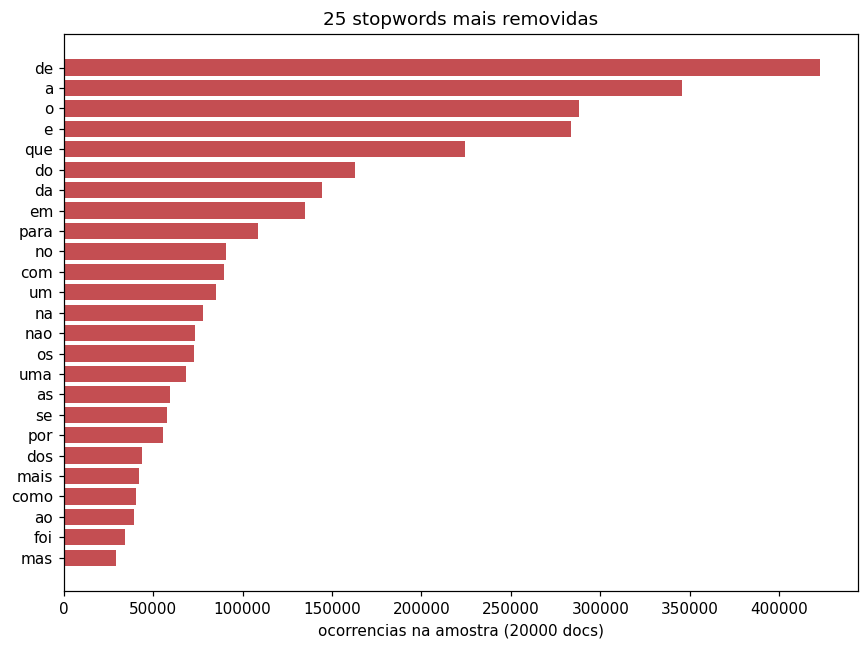

,stopword,ocorrencias
0,de,422953
1,a,345818
2,o,288323
3,e,283851
4,que,224232
5,do,162681
6,da,144211
7,em,134701
8,para,108461
9,no,90419


In [11]:
# frequencia bruta (document-aware) das stopwords efetivamente atingidas na amostra
from collections import Counter

ctr = Counter()
for text in sample["text"]:
    for t in _WORD_RE.findall(text):
        n = _normalize(t)
        if n in STOPWORDS:
            ctr[n] += 1

top_removed = pd.DataFrame(ctr.most_common(25), columns=["stopword", "ocorrencias"])
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_removed["stopword"][::-1], top_removed["ocorrencias"][::-1], color="#C44E52")
ax.set_xlabel(f"ocorrencias na amostra ({len(sample)} docs)")
ax.set_title("25 stopwords mais removidas")
fig.tight_layout()
fig.savefig(FIG_DIR / "top_removed_stopwords.png", bbox_inches="tight")
plt.show()
top_removed.head(15)

## 8. Estratificacao por classe

A remocao de stopwords e uniforme entre classes ou penaliza alguma? Se `mercado`
encolhe muito mais/menos que `outros`, isso afeta a comparabilidade. Comparamos a
fracao media de stopwords e o # de tokens retidos por classe.

In [12]:
by_class = sample.groupby("label_multi").agg(
    n_docs=("text", "size"),
    stop_frac_media=("stop_frac", "mean"),
    tokens_antes_media=("n_tokens", "mean"),
    tokens_depois_media=("n_tokens_after", "mean"),
).reindex(LABELS_MULTI)
by_class["reducao_tokens_%"] = (
    (1 - by_class["tokens_depois_media"] / by_class["tokens_antes_media"]) * 100
).round(2)
by_class = by_class.round({"stop_frac_media": 4, "tokens_antes_media": 1,
                           "tokens_depois_media": 1})
print("por classe (multiclasse 7+other):")
print(by_class)

# visao binaria mercado vs outros
bin_view = sample.assign(bin=sample["label"].map({0: "outros", 1: "mercado"}))
print("\nbinario (mercado vs outros) — fracao media de stopwords:")
print(bin_view.groupby("bin")["stop_frac"].agg(["mean", "median"]).round(4))

por classe (multiclasse 7+other):
             n_docs  stop_frac_media  tokens_antes_media  tokens_depois_media  \
label_multi                                                                     
poder          2609           0.4111               472.9                275.8   
colunas        2701           0.4268               488.5                278.4   
mercado        2510           0.4063               463.7                273.3   
esporte        2309           0.3914               361.8                216.4   
mundo          2100           0.4085               480.7                281.3   
cotidiano      2033           0.4076               439.2                258.0   
ilustrada      1909           0.4030               417.5                246.7   
outros         3829           0.4073               464.8                273.5   

             reducao_tokens_%  
label_multi                    
poder                   41.68  
colunas                 43.00  
mercado                 41.

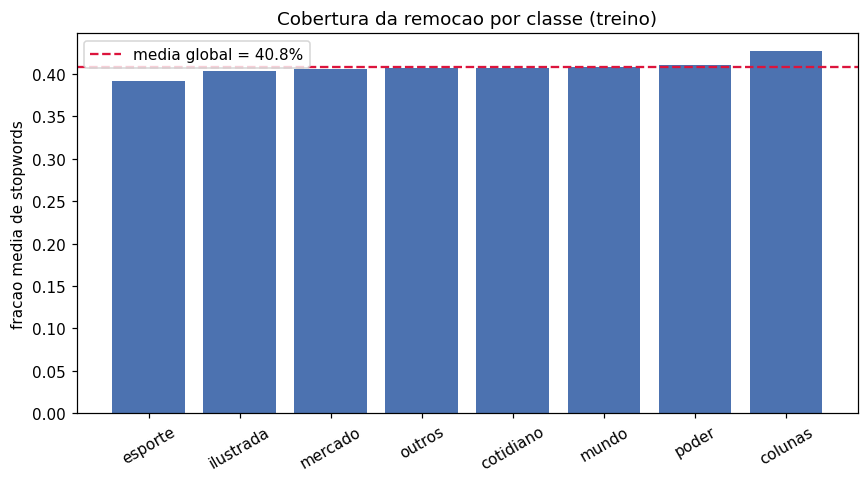

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = by_class["stop_frac_media"].sort_values().index
ax.bar(order, by_class.loc[order, "stop_frac_media"], color="#4C72B0")
ax.axhline(sample["stop_frac"].mean(), color="crimson", ls="--",
           label=f"media global = {sample['stop_frac'].mean():.1%}")
ax.set_ylabel("fracao media de stopwords")
ax.set_title("Cobertura da remocao por classe (treino)")
ax.tick_params(axis="x", rotation=30)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "stop_frac_by_class.png", bbox_inches="tight")
plt.show()

## 9. Exemplos qualitativos antes/depois

In [14]:
def show_example(row):
    print(f"[{row['label_multi']}] tokens {row['n_tokens']} -> {row['n_tokens_after']} "
          f"(removidos {row['n_stop']})")
    print("  ANTES :", row["text"][:240].replace("\n", " "))
    print("  DEPOIS:", row["text_nostop"][:240].replace("\n", " "))
    print()


print("=== exemplo de 'mercado' ===")
mkt = sample[sample["label"] == 1]
if len(mkt):
    show_example(mkt.iloc[0])
print("=== exemplo de 'outros' (maior fracao de stopwords) ===")
show_example(sample.sort_values("stop_frac", ascending=False).iloc[0])
print("=== exemplo tipico (mediano em comprimento) ===")
median_len = sample["n_tokens"].median()
show_example(sample.iloc[(sample["n_tokens"] - median_len).abs().argsort().iloc[0]])

=== exemplo de 'mercado' ===
[mercado] tokens 541 -> 297 (removidos 244)
  ANTES : O trecho da Ferrovia Norte-Sul entre Palmas (TO) e Anápolis (GO), "inaugurado"em 2010 pelo ex-presidente Lula e pela presidente Dilma Rousseff em 2014, completou mais um ano sem uso.  A Valec, responsável pela construção e administração, nã
  DEPOIS: trecho Ferrovia Norte-Sul Palmas (TO) Anápolis (GO), "inaugurado" 2010 ex-presidente Lula presidente Dilma Rousseff 2014, completou ano uso. Valec, responsável construção administração, conseguiu terminar parte liberar passagem trens. previ

=== exemplo de 'outros' (maior fracao de stopwords) ===
[colunas] tokens 5 -> 2 (removidos 3)
  ANTES : O colunista está em férias
  DEPOIS: colunista férias

=== exemplo tipico (mediano em comprimento) ===
[mundo] tokens 403 -> 229 (removidos 174)
  ANTES : As autoridades alemãs afirmaram que, por falta de evidências, foi liberado o suspeito do ataque com um caminhão em Berlim, nesta segunda (19), que deixou 12 mortos e

## 10. Sanidade: idempotencia de `strip_stopwords`

In [15]:
check = sample["text"].head(2000)
once = check.map(strip_stopwords)
twice = once.map(strip_stopwords)
assert (once == twice).all(), "strip_stopwords nao e idempotente!"
print("OK: strip_stopwords e idempotente em 2000 docs (aplicar 2x == aplicar 1x).")
# nenhum token retido deveria ser stopword
leftover = once.map(lambda t: any(_normalize(x) in STOPWORDS for x in _WORD_RE.findall(t)))
print(f"docs com stopword remanescente apos remocao: {int(leftover.sum())} (esperado 0)")

OK: strip_stopwords e idempotente em 2000 docs (aplicar 2x == aplicar 1x).


docs com stopword remanescente apos remocao: 0 (esperado 0)


## 11. Sintese para a metodologia

Pontos a registrar (preencher com os numeros acima ao rodar):

- **Cobertura**: ~`{stop_frac global}` dos tokens do treino sao stopword (a
  remocao corta ~esse tanto de tokens por documento, reduzindo o `nnz`/densidade
  do TF-IDF).
- **Vocabulario nao encolhe — recompoe**: unigramas caem (~`len(stopwords)`
  termos), mas os **bigramas crescem** (`{delta bigramas}%`) porque remover
  stopwords cria adjacencias novas. O vocabulario total pode ate aumentar.
- **Casos-limite**: `{N}` documentos ficam com < 3 tokens apos a remocao —
  ressalva relevante para o BERT `_nostop` (entrada quase-vazia).
- **Equidade entre classes**: a fracao de stopwords e ~uniforme entre `mercado`
  e `outros` (variacao `{}`), entao a remocao **nao introduz vies sistematico**
  entre as formulacoes.
- A analise roda **so no treino** — val/test preservados.

> Esta EDA e descritiva. Se a remocao **melhora** F1/macro-F1 e decidido pelos
> runs `_nostop` comparados via McNemar nos notebooks de modelagem, nao aqui.